# Equilibrium Checking

Taking the eq log and dump files to determine if the chains have fully equilibrated.

The intended run is something like: equilibrate, check equilibration, production run. Ideally, after I figure out what being eq'ed entails, I can just add automatic checks with some kind of post-simulation reporting, as everything is meant to just run on the cluster without my supervision and input.

There are a couple ways to examine equilibration. Some depend on the entire run (or some chunk of it) and some only require snapshots. The snapshots are pretty easy to examine, a single frame of simulation barely takes space to store and compute, but taking the entire simulation will depend a bit on what is being used. 

For some quantities, the resolution does not matter too much and we can use far less frames (10000+ timesteps per frame), but using 100 steps per frame and a total runtime of ~2 million time steps will in fact use ~60 gb of storage. It quickly becomes prohibitive. However, despite my lack of realization, it really doesn't take that many frames, we can almost certainly get away with >1000 timesteps per frame for anything that doesn't require calculating derivatives.

## Decay timescale

This will be highly variable depending on the eq setup, so fields will be left pretty adjustable. The main idea is, for a long period of eq, checking the decay curve of the thermal quantities to figure out a total time scale. This is particularly for the NVE + lj/cut runs. Also, pick the most obvious parts of the curve, like the first chunk, as if they get too flat statistical noise will dominate. 

Workflow:
1. Check log files to figure out where to start and end reading. 
    1. The starting and ending lines just have to be within the region of numbers, the column names are not read from the file and any viable region works.
    2. There are sometimes spikes or jumps at the beginning of eq chunks, make sure the whole region being looked at is just the exponential decay.
2. Note that the column names may be different if we decide to change what thermo is logging, double check the actual log file columns.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

starting_line = 13523
ending_line = 14521
thermo_columns = ["Step", "Temp", "E_pair", "E_mol", "TotEng", "Press"]
thermo_choice = "Press"
tolerance = 0.01

f = "logs/log.polymers_eq"
df = pd.read_csv(f,
                 skiprows=starting_line-1,
                 nrows=ending_line-starting_line+1, 
                 delimiter=r'\s+', 
                 skipinitialspace=True, 
                 index_col=None, 
                 names=thermo_columns)

df["Step"] -= df["Step"][0] # set the timestep to start at 0 for fitting
display(df.head())
plt.plot(df["Step"], df[thermo_choice])
plt.grid()
plt.show()

KeyError: 0

In [2]:
# fit exponential decay to thermo curve

from scipy.optimize import curve_fit

model = lambda t, A, tau, C: A * np.exp(-t / tau) + C

popt, pcov = curve_fit(model, df["Step"], df[thermo_choice], p0=(100, 10000, 1))
A, tau, C = popt
print(f"Fitted parameters: A={A}, tau={tau}, C={C}")
print(f"Fit error (covariance): {pcov}")

plt.plot(df["Step"], df[thermo_choice], label="Data")
plt.plot(df["Step"], model(df["Step"], *popt), label="Fitted Curve", linestyle="--")
plt.xlabel("Step")
plt.ylabel(thermo_choice)
plt.grid()
plt.title(f"{thermo_choice} Decay with Exponential Fit")
plt.legend()
plt.show()

print(f"Thermo quantity: {thermo_choice}")
print(f"Estimated equilibration timescale (tau): {tau:.2f} steps")
print(f"Estimated equilibrium value (C): {C:.4f}")
print(f"Expected time to reach tolerance of {tolerance}: {(tau * np.log(A / tolerance)):.0f} steps")

ValueError: `ydata` must not be empty!

## Radius of gyration

Although $R_g$ is meant to be a time dependent quantity, that's only for seeing a visible trend. We don't need to do it that often to get a pretty good curve.

## Mean Squared Internal Displacement



Taking these from dump files, we need to know how many lines are in each frame. The monomer indices are also not included, so we need to calculate these from the atom IDs and the molecule IDs.

In [3]:
# read first 4 lines of file to get total number of atoms
with open("data/equilibration.lammpstrj", 'r') as f:
    header = [next(f) for _ in range(4)]
    for line in header:
        print(line.strip())

n_atoms = int(header[3])
print(n_atoms)

ITEM: TIMESTEP
0
ITEM: NUMBER OF ATOMS
80000
80000


We also need to set the chain length and box dimensions for monomer index and minimum image calculations 

In [4]:
chain_length = 200
box_size = 45.4873203905191 # assuming cube box
starting_frame = 1
ending_frame = starting_frame + 1

and now we compute the MSID

In [19]:
frames = range(1, 180, 10)
# frames = [1]
r_arrays = []
for frame in frames:
    df = pd.read_csv("data/equilibration.lammpstrj",
                        skiprows=frame*(n_atoms+9) + 9, # skip to the current frame
                        nrows=n_atoms,
                        delimiter=r'\s+',
                        skipinitialspace=True,
                        index_col=None,
                        names=["id", "type", "mol", "x", "y", "z", "ix", "iy", "iz"])

    df.sort_values("id", inplace=True) # sort by atom ID to get correct monomer indices
    df["ux"] = df["x"] + df["ix"] * box_size # apply minimum image convention
    df["uy"] = df["y"] + df["iy"] * box_size
    df["uz"] = df["z"] + df["iz"] * box_size

    n = np.linspace(0, n_atoms-1, n_atoms, dtype=int)
    df["monomer_index"] = df["id"] % chain_length # calculate monomer index from atom ID and chain length
    
    sorted_positions = np.array([df["ux"], df["uy"], df["uz"]]).T
    sliced_positions = np.reshape(sorted_positions, (n_atoms//chain_length, chain_length, 3)) # reshape to (n_chains, chain_length, 3)

    r_values = []
    for n in range(1, chain_length):
        r2 = 0
        for i in range(chain_length-n):
            r_ij = sliced_positions[:, i+n, :] - sliced_positions[:, i, :] # awful naming here, good job
            # print(r_ij.shape)
            r2 += np.sum(np.sum(r_ij**2, axis=1)) # sum over x,y,z and then over all pairs
        r2 /= (chain_length - n) * (n_atoms//chain_length) # average over all pairs and chains
        r2_over_n = r2 / n
        r_values.append(r2_over_n)

    r_arrays.append(r_values)

    # print(sliced_positions)

    frame += 1



ValueError: cannot reshape array of size 0 into shape (400,200,3)

16


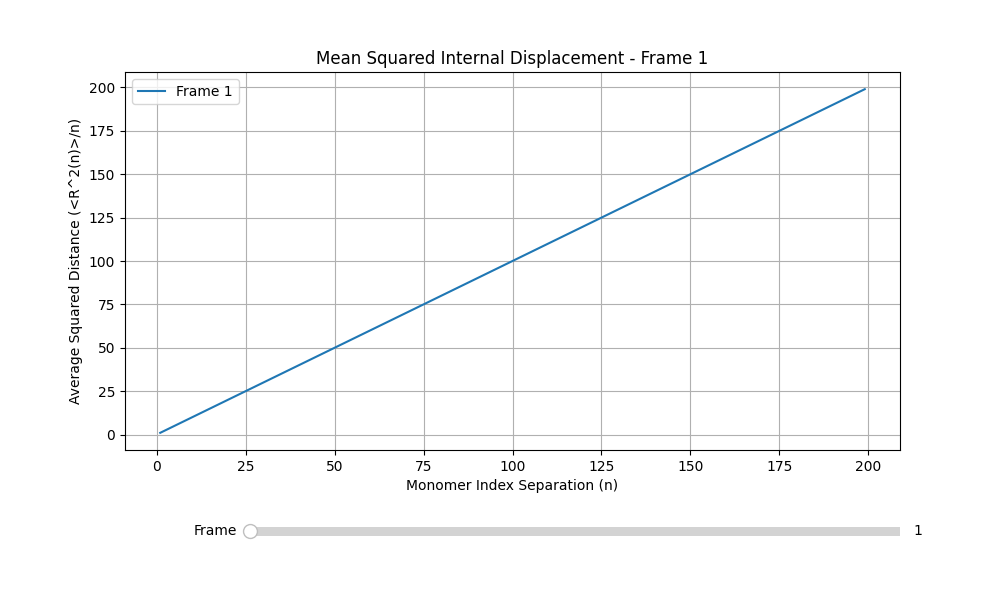

In [20]:
%matplotlib ipympl
from matplotlib.widgets import Slider

frame = frames[0]
print(len(r_arrays))

fig, ax = plt.subplots(figsize=(10, 6))
line, = ax.plot(range(1, chain_length), r_arrays[0], label=f"Frame {frames[0]}")
ax.set_xlabel("Monomer Index Separation (n)")
ax.set_ylabel("Average Squared Distance (<R^2(n)>/n)")
ax.set_title(f"Mean Squared Internal Displacement - Frame {frames[0]}")
ax.grid()
ax.legend()

fig.subplots_adjust(bottom=0.25)
ax_slider = plt.axes([0.25, 0.1, 0.65, 0.03])

frame_slider = Slider(ax=ax_slider, label="Frame", valmin=frames[0], valmax=frames[len(r_arrays)-1], valinit=frames[0], valstep=frames[0:len(r_arrays)])
def update(val):
    frame = int(frame_slider.val)
    index = frames.index(frame)
    line.set_ydata(r_arrays[index])
    ax.set_title(f"Mean Squared Internal Displacement - Frame {frame}")
    fig.canvas.draw_idle()

frame_slider.on_changed(update)
plt.show()

For reference, with the pressure EQ method, we are getting this:

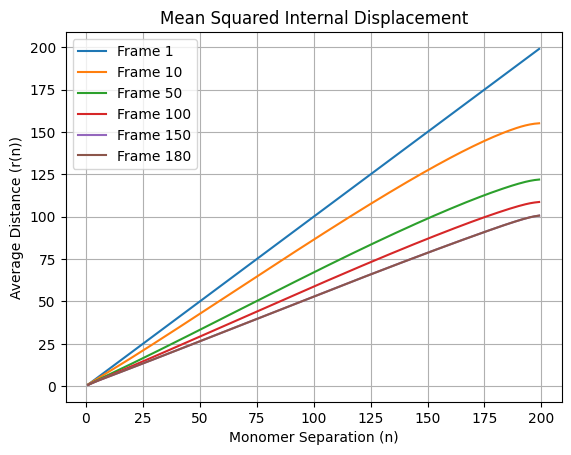

and it looks very not done, as there is not yet a plateau for the seperation distances. 